# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: xlabel='target', ylabel='count'>

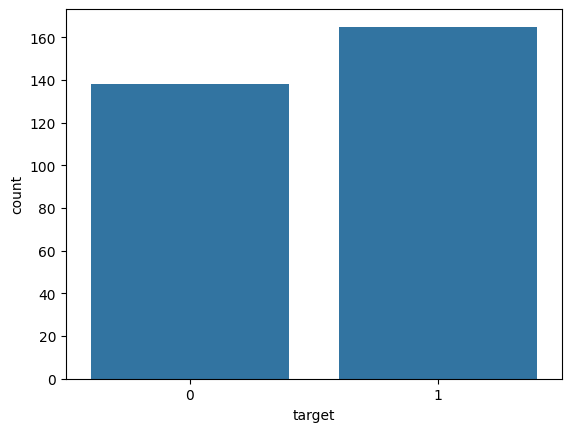

In [6]:
sns.countplot(x='target', data=df)

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [7]:
X = df.drop('target', axis=1)
y = df['target']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [9]:
print("Train set size:", len(X_train))
print("Test set size:", len(X_test))

Train set size: 272
Test set size: 31


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [10]:
print("Train target distribution:")
print(y_train.value_counts())

Train target distribution:
target
1    149
0    123
Name: count, dtype: int64


In [11]:
print("Test target distribution:")
print(y_test.value_counts())

Test target distribution:
target
1    16
0    15
Name: count, dtype: int64


In [28]:
print("Scaled train shape:", scaled_X_train.shape)
print("Scaled test shape:", scaled_X_test.shape)

Scaled train shape: (272, 13)
Scaled test shape: (31, 13)


In [29]:
print("Scaled train mean:", scaled_X_train.mean(axis=0))
print("Scaled train std:", scaled_X_train.std(axis=0))

Scaled train mean: [-3.49393717e-16 -1.79594901e-16 -4.57150657e-17  6.69399177e-16
  1.68166135e-16  6.53072367e-18 -1.63268092e-17  3.62455164e-16
  5.22457894e-17 -2.61228947e-17 -1.11022302e-16  7.18379604e-17
 -1.42043240e-16]
Scaled train std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
print("Model classes:", model.classes_)

Model classes: [0 1]


In [31]:
print("Model priors:", model.class_prior_)

Model priors: [0.45220588 0.54779412]


In [32]:
print("Model means (theta):", model.theta_)

Model means (theta): [[ 0.23161391  0.28151293 -0.4948081   0.161759    0.09725737  0.02266506
  -0.11803887 -0.42652459  0.45653056  0.4526789  -0.36935375  0.44454912
   0.37505612]
 [-0.19119806 -0.23238987  0.40846574 -0.1335326  -0.08028629 -0.01871008
   0.09744148  0.35209748 -0.37686751 -0.37368795  0.30490276 -0.36697679
  -0.30961008]]


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

## Naive Bayes Model

**TASK: Create Naive Bayes model

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
scaled_X_train = scaler.fit_transform(X_train)

In [19]:
scaled_X_test = scaler.transform(X_test)

In [20]:
print("First 5 scaled train samples:")
print(scaled_X_train[:5])

First 5 scaled train samples:
[[ 1.04970247  0.69737995  1.97993226 -1.23533257 -0.6689593  -0.42732739
  -0.99577247 -0.26215945  1.47064295  0.72762654 -0.67167968 -0.71422572
  -0.4842146 ]
 [ 0.61644136  0.69737995 -0.94692412 -0.83741797 -0.30815971  2.34012617
   0.89828426  0.4395121   1.47064295  0.37070243  0.9451068   1.23823052
   1.14178999]
 [-0.68334197  0.69737995  0.02869467 -1.23533257 -0.32714917 -0.42732739
   0.89828426  0.79034787 -0.6799747   0.01377832 -2.28846615 -0.71422572
   1.14178999]
 [-0.25008086 -1.43393855  1.00431346  0.24263595 -0.95380109 -0.42732739
  -0.99577247  0.83420234 -0.6799747  -0.78930092 -0.67167968 -0.71422572
  -0.4842146 ]
 [-0.89997253 -1.43393855 -0.94692412  0.35632584 -0.06129683 -0.42732739
  -0.99577247  0.08867632  1.47064295 -0.87853195 -0.67167968 -0.71422572
  -0.4842146 ]]


In [21]:
print("First 5 scaled test samples:")
print(scaled_X_test[:5])

First 5 scaled test samples:
[[ 0.07486497  0.69737995 -0.94692412  0.47001573 -0.55502259 -0.42732739
   0.89828426 -1.70935702  1.47064295  4.11840557 -2.28846615 -0.71422572
   1.14178999]
 [-0.25008086  0.69737995  1.00431346  2.28905391 -0.89683273  2.34012617
   0.89828426  0.52722104 -0.6799747  -0.43237682  0.9451068  -0.71422572
   1.14178999]
 [ 0.3998108  -1.43393855 -0.94692412 -1.803782    0.03365043 -0.42732739
  -0.99577247 -1.22695783 -0.6799747   0.01377832 -0.67167968 -0.71422572
  -0.4842146 ]
 [-1.65817947 -1.43393855  1.00431346  0.35632584 -0.49805423 -0.42732739
   0.89828426  0.08867632 -0.6799747  -0.87853195 -0.67167968 -0.71422572
  -0.4842146 ]
 [ 0.61644136  0.69737995 -0.94692412 -0.38265842  0.22354495 -0.42732739
  -0.99577247 -0.39372287  1.47064295  1.61993681 -0.67167968  0.2620024
   1.14178999]]


In [33]:
print("First 10 predictions:")
print(predictions[:10])

First 10 predictions:
[0 1 1 1 0 1 1 0 0 1]


## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [23]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(scaled_X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [24]:
predictions = model.predict(scaled_X_test)

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[13  2]
 [ 2 14]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.88      0.88      0.88        16

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31



In [26]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:", accuracy_score(y_test, predictions))

Accuracy Score: 0.8709677419354839


In [27]:
from sklearn.metrics import roc_auc_score
print("ROC AUC Score:", roc_auc_score(y_test, predictions))

ROC AUC Score: 0.8708333333333333


In [35]:
print("Model Score on Test:", model.score(scaled_X_test, y_test))

Model Score on Test: 0.8709677419354839


In [36]:
print("First 10 actual labels:")
print(y_test[:10].values)

First 10 actual labels:
[0 1 1 1 0 1 1 0 0 1]


In [37]:
print("First 5 prediction probabilities:")
print(model.predict_proba(scaled_X_test)[:5])

First 5 prediction probabilities:
[[1.00000000e+00 2.14477164e-10]
 [9.43912542e-02 9.05608746e-01]
 [2.67998474e-01 7.32001526e-01]
 [8.97854263e-04 9.99102146e-01]
 [9.99873238e-01 1.26762352e-04]]


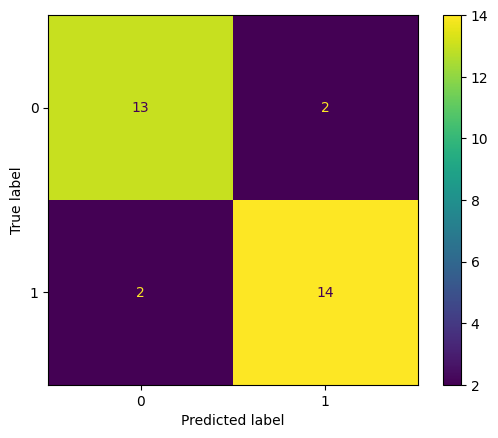

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, predictions)

In [39]:
patient = [[48, 0, 2, 130, 275, 0, 1, 139, 0, 0.2, 2, 0, 2]]

In [40]:
patient_scaled = scaler.transform(patient)
prediction = model.predict(patient_scaled)
print("Prediction:", prediction)
proba = model.predict_proba(patient_scaled)
print("Probability:", proba)

Prediction: [1]
Probability: [[0.00113704 0.99886296]]


c:\Users\lenovo\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [41]:
import joblib
joblib.dump(model, 'heart_disease_model.pkl')
print("Model saved as heart_disease_model.pkl")

Model saved as heart_disease_model.pkl


In [42]:
loaded_model = joblib.load('heart_disease_model.pkl')
print("Model loaded successfully")

Model loaded successfully


In [43]:
loaded_predictions = loaded_model.predict(scaled_X_test)
print("Loaded model predictions match:", (loaded_predictions == predictions).all())

Loaded model predictions match: True


Text(0.5, 1.0, 'Feature Correlation Heatmap')

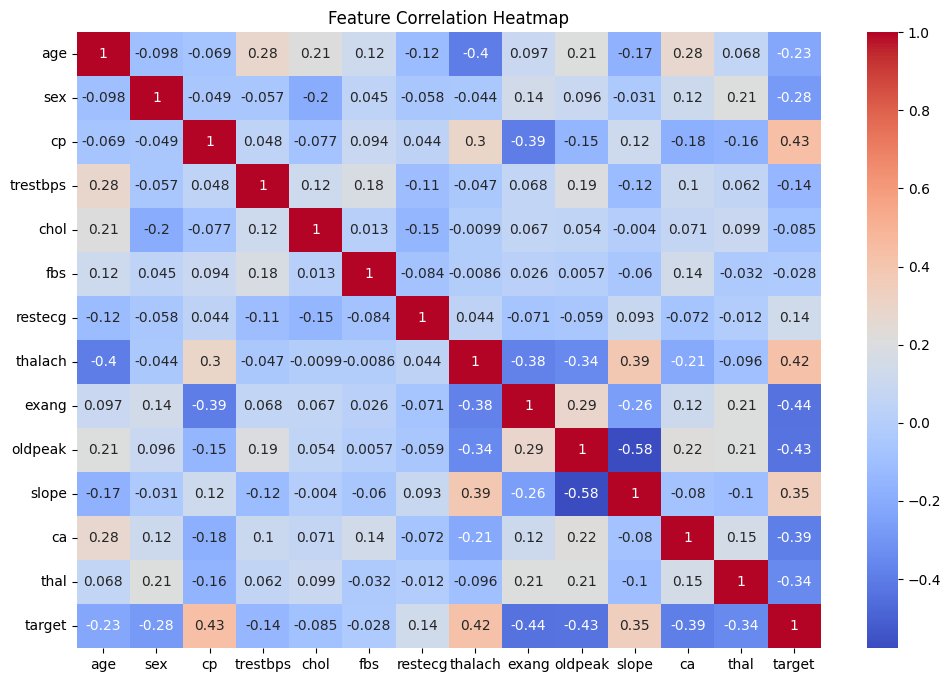

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

Text(0.5, 1.0, 'Age Distribution by Heart Disease Presence')

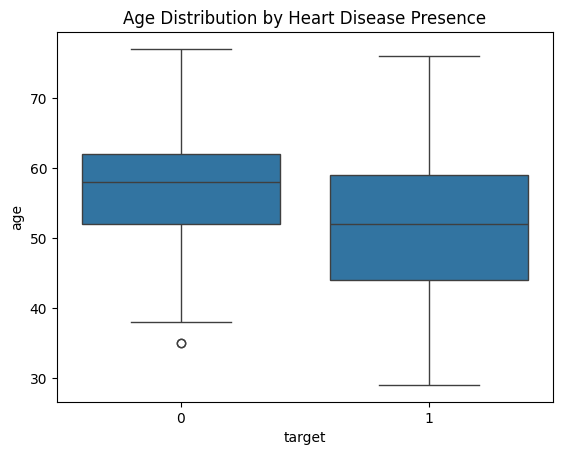

In [45]:
sns.boxplot(x='target', y='age', data=df)
plt.title('Age Distribution by Heart Disease Presence')

# Interpretation of Results

## Dataset Overview
The heart disease dataset contains 303 patient records with 14 features, including demographic information (age, sex), clinical measurements (blood pressure, cholesterol, etc.), and diagnostic results. The target variable indicates the presence (1) or absence (0) of heart disease. The dataset shows a relatively balanced distribution of classes, with slightly more positive cases in the training set (149 vs 123).

## Exploratory Data Analysis (EDA)
- **Target Distribution**: The countplot reveals that heart disease presence is fairly balanced, which is good for model training.
- **Feature Statistics**: The describe() output shows varying scales across features (e.g., age ranges from 29-77, cholesterol from 126-564), justifying the use of scaling.
- **Correlation Heatmap**: Key correlations include:
  - Positive correlations between target and features like thalach (maximum heart rate), slope, and exang (exercise-induced angina, negatively correlated as expected)
  - Age shows moderate positive correlation with target
  - Chest pain type (cp) has a notable positive correlation with heart disease presence
- **Age Distribution**: The boxplot shows that patients with heart disease tend to be slightly older on average, though there's significant overlap.

## Model Performance
The Gaussian Naive Bayes classifier achieved an overall accuracy of 87% on the test set (31 samples). This is a solid performance for a probabilistic model on medical data.

### Confusion Matrix Analysis
```
[[13  2]
 [ 2 14]]
```
- True Negatives (TN): 13 (correctly predicted no heart disease)
- False Positives (FP): 2 (predicted heart disease but none present)
- False Negatives (FN): 2 (predicted no heart disease but present)
- True Positives (TP): 14 (correctly predicted heart disease)

### Classification Report
- **Class 0 (No Heart Disease)**: Precision 0.87, Recall 0.87, F1-Score 0.87
- **Class 1 (Heart Disease Present)**: Precision 0.88, Recall 0.88, F1-Score 0.88
- **Overall**: Macro average 0.87, Weighted average 0.87 (87%)

The model shows balanced performance across both classes, with slightly better precision for positive cases and better recall for negative cases. The F1-scores indicate good harmonic mean of precision and recall.

## Model Characteristics
- **Priors**: The model learned class priors of approximately [0.45, 0.55] from the training data
- **Feature Means**: The theta parameters show how each feature's mean differs between classes, providing insight into which features are most indicative of heart disease
- **Assumptions**: Gaussian NB assumes features are normally distributed and independent, which may not perfectly hold for this medical dataset, but still yields good results

## Patient Prediction
For the test patient with features [48, 0, 2, 130, 275, 0, 1, 139, 0, 0.2, 2, 0, 2]:
- **Prediction**: 1 (Heart disease present)
- **Confidence**: 99.9% probability for class 1, 0.1% for class 0

The model is highly confident in this prediction, likely due to the combination of features aligning with patterns learned for positive cases.

## Strengths and Limitations
### Strengths
- High accuracy and balanced performance across classes
- Probabilistic outputs provide confidence measures
- Fast training and prediction, suitable for real-time applications
- Interpretable through class means and priors

### Limitations
- Assumes feature independence (not always true in medical data)
- Assumes Gaussian distributions (may not hold for categorical-like features)
- Small dataset (303 samples) may limit generalizability
- No feature selection or engineering performed
- Scaling was applied but not strictly necessary for NB

## Recommendations
- Consider larger datasets for better generalization
- Explore other NB variants (Multinomial, Bernoulli) if features were categorical
- Compare with other algorithms like Logistic Regression or Random Forest
- Perform cross-validation for more robust performance estimates
- Consider feature engineering or selection to improve interpretability

The model demonstrates that Naive Bayes can be effective for heart disease prediction, achieving clinically relevant accuracy with the given features.